In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
files.upload()

Saving PS 1.xlsx to PS 1 (1).xlsx


{'PS 1 (1).xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00LA\x02\x11_\x01\x00\x00\x90\x04\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [3]:
df = pd.read_excel("PS 1.xlsx") # Load dataset
df.head()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength,VariantLabel
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


Numerical or categorical?
All features except VariantLabel are numerical (continuous variables)
VariantLabel is a categorical variable representing different fruit types (e.g., Kecimen, etc.)

Therefore, this is a supervised classification problem with numerical predictors and a categorical target

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PixelMass       900 non-null    int64  
 1   LongAxisSpan    900 non-null    float64
 2   ShortAxisSpan   900 non-null    float64
 3   ShapeDeviation  900 non-null    float64
 4   HullMass        900 non-null    int64  
 5   DensityRatio    900 non-null    float64
 6   BoundaryLength  900 non-null    float64
 7   VariantLabel    900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


# 1. Exploratory Structural Analysis (ESA)
## a) Structural Audit
1. Data types
2. Feature ranges
3. Missing values




In [5]:
df.describe()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


Missing Value: No missing values are present in the dataset.
The dataset is clean and does not require imputation

In [6]:
df.isnull().sum()

,0
PixelMass,0
LongAxisSpan,0
ShortAxisSpan,0
ShapeDeviation,0
HullMass,0
DensityRatio,0
BoundaryLength,0
VariantLabel,0


The dataset contains seven numerical features related to geometric properties of dried fruits and one categorical target variable (VariantLabel). All predictor variables are continuous, while the target represents class labels. A missing value analysis using isnull() shows that the dataset contains no missing values, indicating it is clean and ready for further processing.

In [7]:
df.isnull().sum()
df.describe()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


Very large/small values → scaling issue

Skewed distributions

Hidden Patterns - Scale imbalance

In [8]:
df.describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
PixelMass,25387.000000,235047.000000,87804.127778,39002.111390
LongAxisSpan,225.629541,997.291941,430.929950,116.035121
ShortAxisSpan,143.710872,492.275279,254.488133,49.988902
ShapeDeviation,0.348730,0.962124,0.781542,0.090318
HullMass,26139.000000,278217.000000,91186.090000,40769.290132
DensityRatio,0.379856,0.835455,0.699508,0.053468
BoundaryLength,619.074000,2697.753000,1165.906636,273.764315


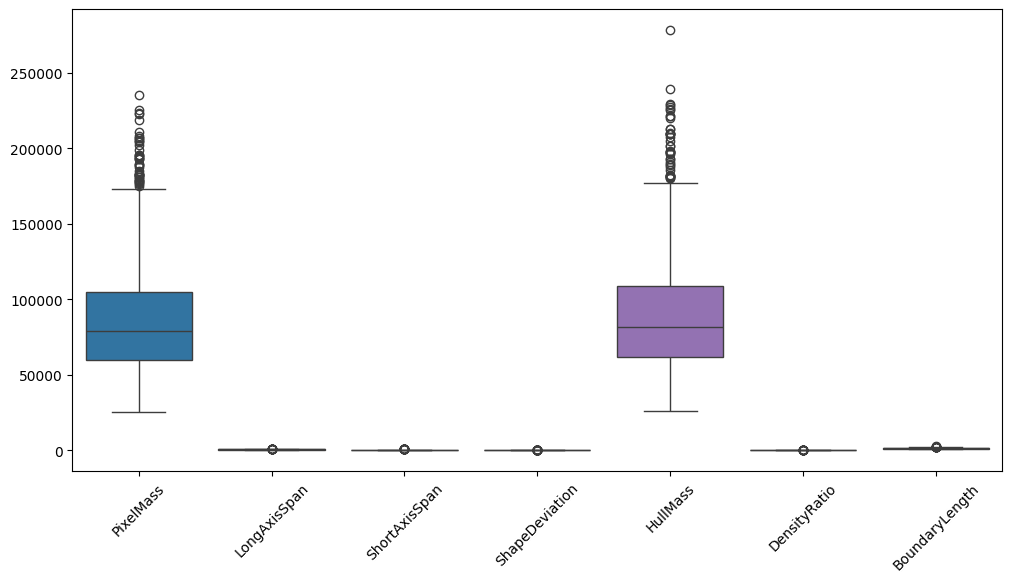

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop('VariantLabel', axis=1))
plt.xticks(rotation=45)
plt.show()

In [10]:
df.std(numeric_only=True)

,0
PixelMass,39002.111390
LongAxisSpan,116.035121
ShortAxisSpan,49.988902
ShapeDeviation,0.090318
HullMass,40769.290132
DensityRatio,0.053468
BoundaryLength,273.764315


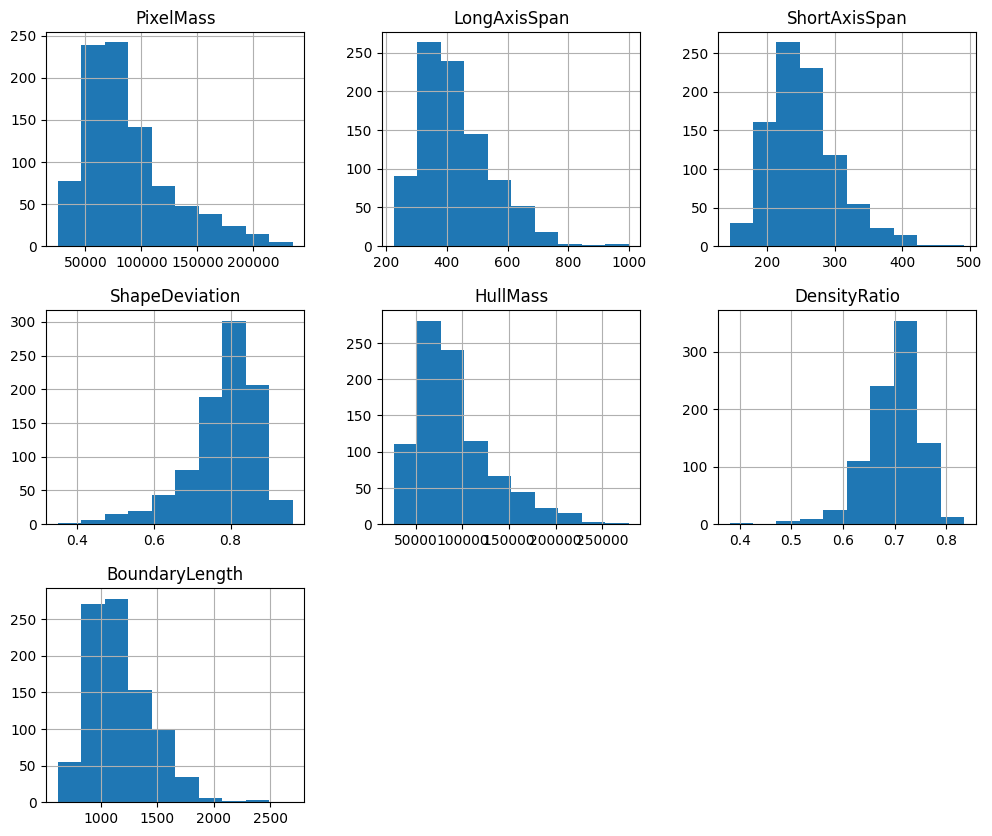

In [11]:
df.hist(figsize=(12,10))
plt.show()

Scale Imbalance: Features are in different units/ranges

Example:
PixelMass → thousands

DensityRatio → small decimals

Problem: Models like Logistic Regression get biased toward large-scale features

Other Hidden Patterns (you can mention)
1. Skewness (right/left skewed)
2. Outliers
3. Feature clustering


A structural audit of feature distributions reveals the presence of scale imbalance across variables. Summary statistics indicate that features such as PixelMass and HullMass have significantly larger ranges compared to features like DensityRatio. This is further confirmed through boxplot visualization, where certain features dominate the scale while others appear compressed. Such imbalance can negatively impact distance-based and gradient-based models by giving undue importance to higher magnitude features. Therefore, feature scaling techniques such as StandardScaler or RobustScaler are required before model training.

## b) Multi-perspective visualizations


Distribution Plots (Univariate)

<Axes: xlabel='PixelMass', ylabel='Count'>

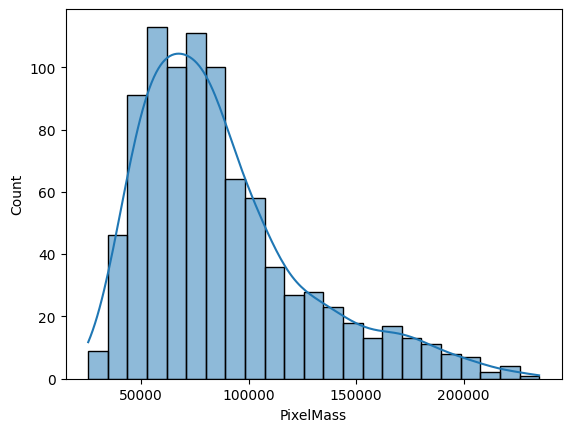

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['PixelMass'], kde=True)

Pairwise relationships (bivariate)  

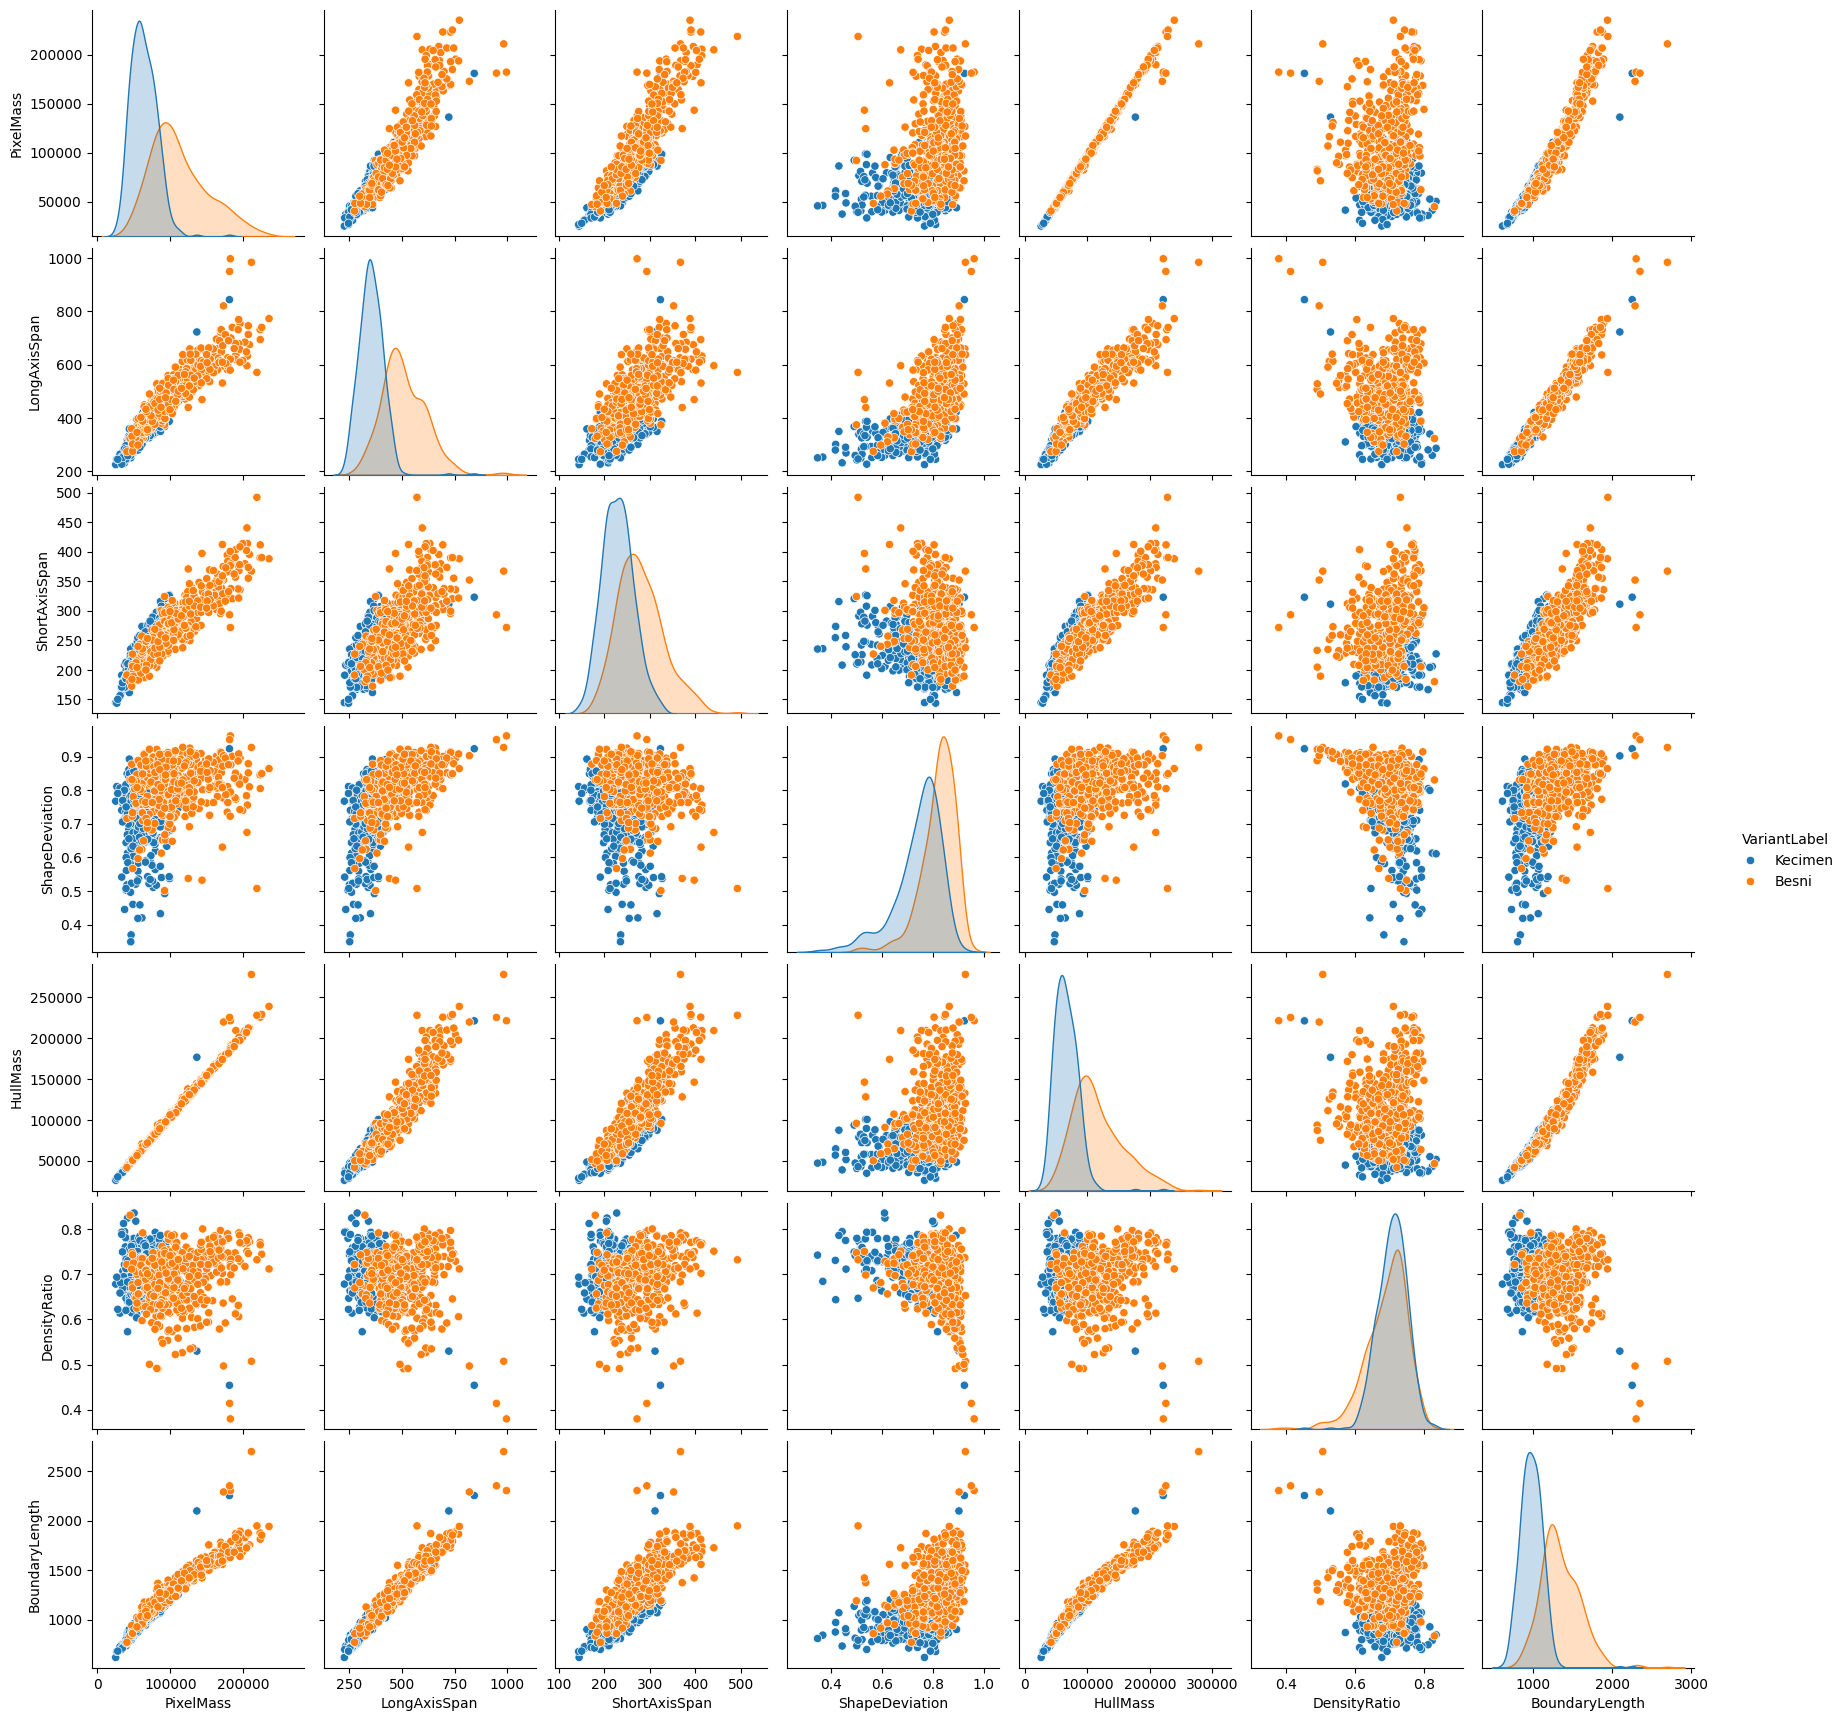

In [13]:
sns.pairplot(df, hue='VariantLabel')

Class-conditional feature distributions  

<Axes: xlabel='VariantLabel', ylabel='PixelMass'>

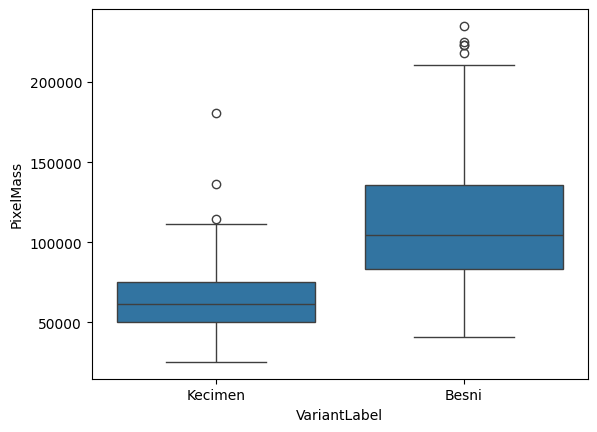

In [14]:
sns.boxplot(x='VariantLabel', y='PixelMass', data=df)

## c) Feature interaction structure

Correlation matrix


In [15]:
print(df.dtypes)

PixelMass           int64
LongAxisSpan      float64
ShortAxisSpan     float64
ShapeDeviation    float64
HullMass            int64
DensityRatio      float64
BoundaryLength    float64
VariantLabel       object
dtype: object


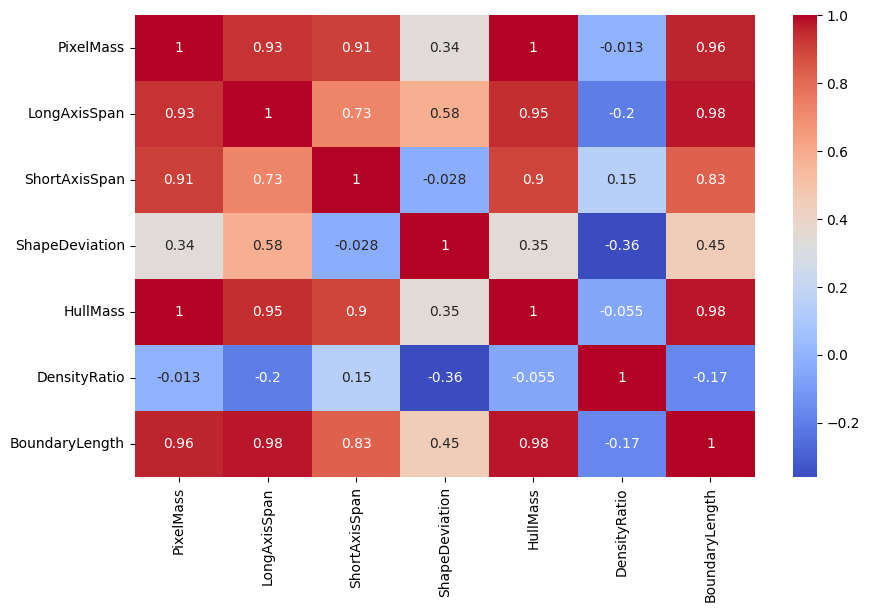

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Mutual information (MANDATORY)

In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['VariantLabel'])

X = df.drop('VariantLabel', axis=1)

mi = mutual_info_classif(X, y)

mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi})
mi_df.sort_values(by='MI Score', ascending=False)

,Feature,MI Score
6,BoundaryLength,0.358507
1,LongAxisSpan,0.348341
4,HullMass,0.297654
0,PixelMass,0.277582
2,ShortAxisSpan,0.134869
3,ShapeDeviation,0.129117
5,DensityRatio,0.029344


## d) Why correlation is insufficient?

1. Correlation captures linear relationships only
2. Mutual Information captures non-linear dependencies

Example: XOR → zero correlation but strong dependency

# 2. Data Conditioning & Representation Learning

## a) Data sanitization pipeline

IQR

In [19]:
df_num = df.select_dtypes(include='number')

In [20]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

mask = ~((df_num < (Q1 - 1.5*IQR)) | (df_num > (Q3 + 1.5*IQR))).any(axis=1)

df_out = df[mask]   # ✅ keeps all columns

Isolation Forest

In [21]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest()
df['outlier'] = iso.fit_predict(X)

Skewness Correction

In [25]:
df.skew(numeric_only=True)

,0
PixelMass,1.175237
LongAxisSpan,0.989544
ShortAxisSpan,0.800049
ShapeDeviation,-1.327503
HullMass,1.242904
DensityRatio,-1.151505
BoundaryLength,1.017761
outlier,-1.620433
AspectRatio,0.934340


Skewness > 1 → highly skewed

0.5 to 1 → moderately skewed

< 0.5 → approximately normal

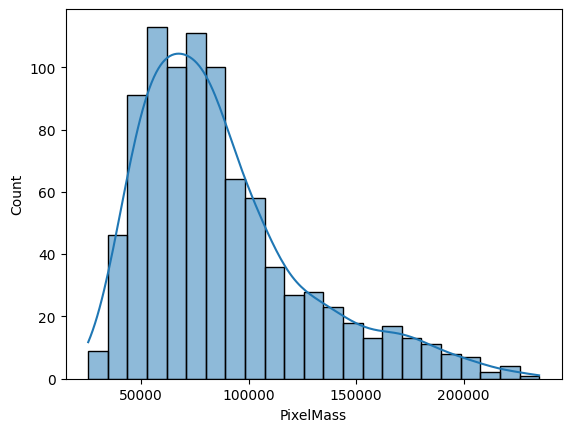

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['PixelMass'], kde=True)
plt.show()

In [27]:
#Method 1: Log Transformation
#When to use:
#Right-skewed data
#No zero/negative values
import numpy as np

df['PixelMass_log'] = np.log1p(df['PixelMass'])

#log1p = log(1 + x) → handles zero safely

In [28]:
#Method 2: Box-Cox Transformation
#When to use:
#Positive data only
#Want optimal normalization
from scipy.stats import boxcox

df['PixelMass_boxcox'], _ = boxcox(df['PixelMass'] + 1)

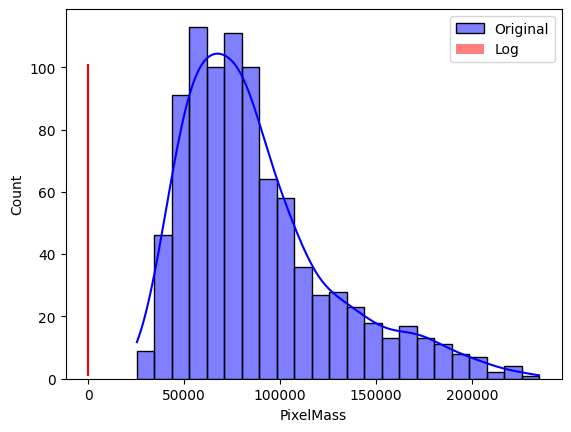

In [29]:
sns.histplot(df['PixelMass'], color='blue', label='Original', kde=True)
sns.histplot(df['PixelMass_log'], color='red', label='Log', kde=True)
plt.legend()
plt.show()

## b) Representation transformation techniques

Standardization vs Normalization vs Robust Scaling

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)

scaler_rb = RobustScaler()
X_rb = scaler_rb.fit_transform(X)

Justify mathematically which is suitable and why

Use RobustScaler → handles outliers better

Use StandardScaler → if data is normal

Robust Scaling is preferred because it uses median and IQR, which are less sensitive to outliers compared to mean and standard deviation used in Standardization, or min-max values used in normalization.

## c) Feature importance estimation using at least two paradigms:

Model-based (e.g., tree importance)

In [30]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Features and target
X = df.drop('VariantLabel', axis=1)
y = df['VariantLabel']

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Get importance
importance = rf.feature_importances_

# Convert to DataFrame
feat_imp_model = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feat_imp_model

#Based on how much each feature reduces impurity (Gini/Entropy)
#Higher value = more important

,Feature,Importance
6,BoundaryLength,0.213389
1,LongAxisSpan,0.172740
4,HullMass,0.115937
10,PixelMass_boxcox,0.109576
0,PixelMass,0.086680
9,PixelMass_log,0.083763
3,ShapeDeviation,0.064152
8,AspectRatio,0.057145
5,DensityRatio,0.049505
2,ShortAxisSpan,0.046180


Statistical (e.g., ANOVA / MI)

In [31]:
# Mutual Information
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

mi = mutual_info_classif(X, y_encoded)

feat_imp_mi = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi
}).sort_values(by='MI Score', ascending=False)

feat_imp_mi

,Feature,MI Score
6,BoundaryLength,0.358507
1,LongAxisSpan,0.348341
4,HullMass,0.297654
9,PixelMass_log,0.277981
10,PixelMass_boxcox,0.277912
0,PixelMass,0.277860
2,ShortAxisSpan,0.134869
8,AspectRatio,0.129586
3,ShapeDeviation,0.129117
5,DensityRatio,0.029344


In [32]:
# ANOVA (F-Test)
from sklearn.feature_selection import f_classif

f_values, p_values = f_classif(X, y_encoded)

feat_imp_anova = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_values,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

feat_imp_anova

,Feature,F-Score,p-value
1,LongAxisSpan,744.251543,7.675738e-120
6,BoundaryLength,715.744169,2.015660e-116
9,PixelMass_log,688.761586,3.954642e-113
10,PixelMass_boxcox,687.129366,6.281818e-113
0,PixelMass,577.808076,5.684800e-99
4,HullMass,577.356620,6.523457e-99
2,ShortAxisSpan,304.321568,6.515103e-59
8,AspectRatio,261.539781,8.011809e-52
3,ShapeDeviation,213.774500,1.382867e-43
7,outlier,28.152818,1.412871e-07


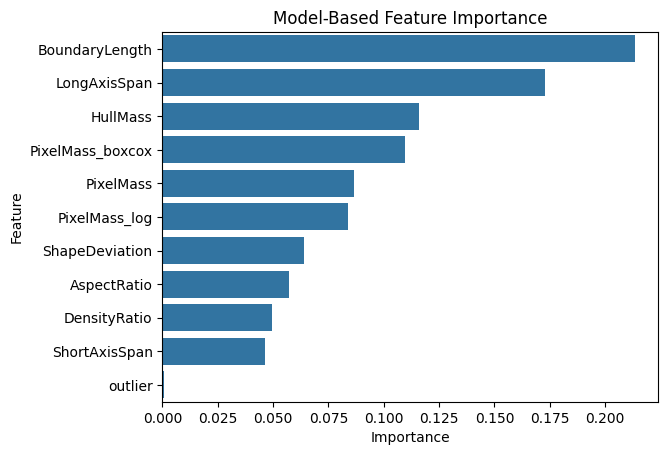

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Importance', y='Feature', data=feat_imp_model)
plt.title("Model-Based Feature Importance")
plt.show()

In [34]:
print(feat_imp_model)
print(feat_imp_mi)

             Feature  Importance
6     BoundaryLength    0.213389
1       LongAxisSpan    0.172740
4           HullMass    0.115937
10  PixelMass_boxcox    0.109576
0          PixelMass    0.086680
9      PixelMass_log    0.083763
3     ShapeDeviation    0.064152
8        AspectRatio    0.057145
5       DensityRatio    0.049505
2      ShortAxisSpan    0.046180
7            outlier    0.000933
             Feature  MI Score
6     BoundaryLength  0.358507
1       LongAxisSpan  0.348341
4           HullMass  0.297654
9      PixelMass_log  0.277981
10  PixelMass_boxcox  0.277912
0          PixelMass  0.277860
2      ShortAxisSpan  0.134869
8        AspectRatio  0.129586
3     ShapeDeviation  0.129117
5       DensityRatio  0.029344
7            outlier  0.011546


Feature importance was computed using Random Forest (model-based) and Mutual Information/ANOVA (statistical). Random Forest evaluates impurity reduction, while MI captures dependency and ANOVA tests class separation. Combining both ensures robust feature selection.

## d)  Construct at least one derived feature based on domain intuition (e.g., shape ratio) and justify it.

In [24]:
df['AspectRatio'] = df['LongAxisSpan'] / df['ShortAxisSpan']

Shape differences are important in fruit classification